In [75]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Présentation du projet

Projet du cours d'Introduction au Machine Learning pour l'Image (IMLI)<br>
Promo : IMAGE 2026<br>
Enseignants : Guillaume Tochon & Joseph Chazalon

## Chargement et présentation des données

Les données qui sont mises à votre disposition pour ce projet sont celles du [_IEEE GRSS Data Fusion Contest 2013_](http://www.classic.grss-ieee.org/community/technical-committees/data-fusion/2013-ieee-grss-data-fusion-contest/). Le Data Fusion Contest de l'IEEE GRSS (Geoscience and Remote Sensing Society) est un challenge organisé chaque année par les membres du chapitre GRSS de l'association IEEE, qui est ouvert à tout chercheur, doctorant, étudiant, etc., et qui met en oeuvre des problématiques de fusion d'information (multi-capteurs, multi-dates, multi-sites, etc.) pour des applications en télédétection (imagerie satellitaire).

Les données du projet, présentées ci-dessous, ont été acquises au dessus de l'université de Houston en 2012, et se composent d'une image hyperpsectale de 144 bandes couvrant la portion $380-1050~$nm du spectre éléctromagnétique, et d'une image LiDAR. Les deux images sont à la même résolution spatiale de 2.5 m/pixel, et sont co-registrées (chaque pixel de l'une couvre exactement la même surface au sol que le pixel correspondant de l'autre image).

### Téléchargement et extraction des données

In [76]:
%%bash
if [ -d "data" ]; then
    echo "Le dossier data existe déjà"
else
    mkdir -p "data"
    wget -q "https://www.lrde.epita.fr/~gtochon/IML/data.zip" -P "data"
    unzip -q "data/*.zip" -d "data"
    rm "data/"*.zip*
fi

Le dossier data existe déjà


### Image LIDAR ([plus d'infos ici](https://fr.wikipedia.org/wiki/Lidar))

Une image acquise par un capteur LiDAR fournit un modèle d'élévation de terrain (DSM, pour _digital surface model_). La scène est illuminée par un laser, et le capteur mesure le délai nécessaire à l'écho laser pour revenir depuis la cible. Connaissant la vitesse de déplacement du laser (vitesse de la lumière) et le temps nécessaire au laser pour faire l'aller/retour jusqu'à la scène, on peut en déduire facilement la distance. Lorsque le capteur LiDAR est embarqué sur un avion, la connaissance supplémentaire de l'altitude de vol de l'avion permet d'en déduire au final la hauteur du terrain (normalisée par rapport à une hauteur 0 fixée de manière arbitraire) : plus la valeur d'un pixel est élevée dans l'image LiDAR, plus la zone au sol correpondante est haute.

In [77]:
lidar = np.load("data/lidar.npy")
print("L'image LiDAR est composée de %d lignes et %d colonnes "%(lidar.shape)+"au format %s"%lidar.dtype)

L'image LiDAR est composée de 349 lignes et 1905 colonnes au format float32


#### Visualisation du LiDAR

In [78]:
print("Valeur min = %1.3f et valeur max = %1.3f dans l'image LiDAR"%(lidar.min(),lidar.max()))

Valeur min = 4.420 et valeur max = 70.852 dans l'image LiDAR


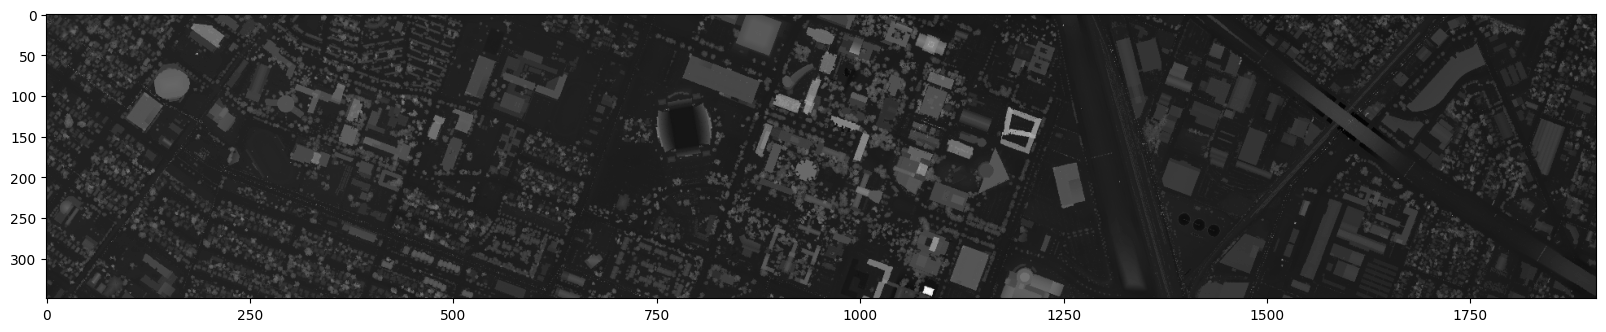

In [79]:
plt.figure(figsize=(20,5))
plt.imshow(lidar, cmap='gray')
plt.show()

### Image hyperspectrale ([plus d'infos ici](https://fr.wikipedia.org/wiki/Imagerie_hyperspectrale))

Les images hyperspectrales sont des "extensions" des images RGB traditionnelles dans le sens où elles n'ont plus 3 canaux, mais des centaines (voire des milliers). 
Un capteur hyperspectral échantillonne finement le spectre électromagnétique en collectant la quantité de lumière reçue dans de fines bandes de longueur d'onde (typiquement, une bande spectrale correspond a une largeur de quelques nanomètres). Au final, on obtient un cube de données avec $N$ canaux, et un pixel $\mathbf{x}$ n'est plus un triplet $\mathbf{x} = [x_R, x_G, x_B]$ comme pour une image RGB, mais un $N$-uplet $\mathbf{x} = [x_1,\dots,x_N] \in \mathbb{R}^N$ où chaque valeur $x_i$ correspond à la quantité de lumière qui a été reçue dans la $i$ème bande. Comme chaque bande est associée à une longueur d'onde particulière dans le spectre électromagnétique, tracer $\mathbf{x}$ en fonction de $i$ donne un _spectre de réflectance,_ en d'autres termes, comment la lumière qui atteint le capteur a interagi avec la matière dans la scène imagée. Comme deux matériaux différents (par exemple la végétation et le bitume) n'interagissent pas de la même manière avec la lumière, une image hyperspectrale permet d'identifier les composants macroscopiques (végétation, terre, métal, béton, eau, etc) présents dans la scène imagée. Les capteurs hyperspectraux sont largement utilisés dans le domaine de l'imagerie satellitaire (embarqués dans des avions et des satellites) à des fins d'observation de la Terre.

In [80]:
hsi_raw = np.load("data/hyperspectral.npy")
print("L'image hyperspectrale est composée de %d lignes, %d colonnes et %d bandes "%(hsi_raw.shape)
      +"au format %s"%hsi_raw.dtype)

L'image hyperspectrale est composée de 349 lignes, 1905 colonnes et 144 bandes au format uint16


#### Visualisation de l'image hyperspectrale

In [81]:
print("Valeur min = %d et valeur max = %d dans l'image hyperspectrale"%(hsi_raw.min(),hsi_raw.max()))

Valeur min = 0 et valeur max = 65517 dans l'image hyperspectrale


Une image hyperspectrale étant composée de centaines (voir milliers) de bandes, sa visualisation n'est pas directe : on ne peut pas demander à une routine de visualisation d'afficher telle quelle une image hyperspectrale. Il faut au préalable en extraire une version RGB, en sélectionnant 3 bandes spectrales (c'est-à-dire, 3 tranches du cube de données) dont les longueurs d'ondes correspondent à celles du rouge, du vert et du bleu.

Ici, l'intervalle de longueur d'ondes $380-1050~$nm est subdivisé en 144 bandes spectrales, et prenant comme longueurs d'ondes de référence 465 nm pour le bleu, 532 nm pour le vert et 630 nm pour le rouge, on peut calculer les bandes RGB suivantes : R = 54$^e$ bande, G = 32$^e$ bande et B = 18$^e$ bande.

In [82]:
rgb_bands = [54,32,18]
hsi_rgb = hsi_raw[:,:,rgb_bands]
hsi_rgb = hsi_rgb/hsi_rgb.max() # normalisation des valeurs dans [0,1] pour l'affichage

In [83]:
# Don't mind me, I'm just here to pimp a little bit the RGB image
pmin,pmax = np.percentile(hsi_rgb,(1,95),axis=(0,1))
hsi_rgb_pimped = hsi_rgb.copy()
for i in range(pmin.size):
    hsi_rgb_pimped[:,:,i] = (hsi_rgb[:,:,i]-pmin[i])/(pmax[i]-pmin[i])
hsi_rgb_pimped[hsi_rgb_pimped<0] = 0
hsi_rgb_pimped[hsi_rgb_pimped>1] = 1

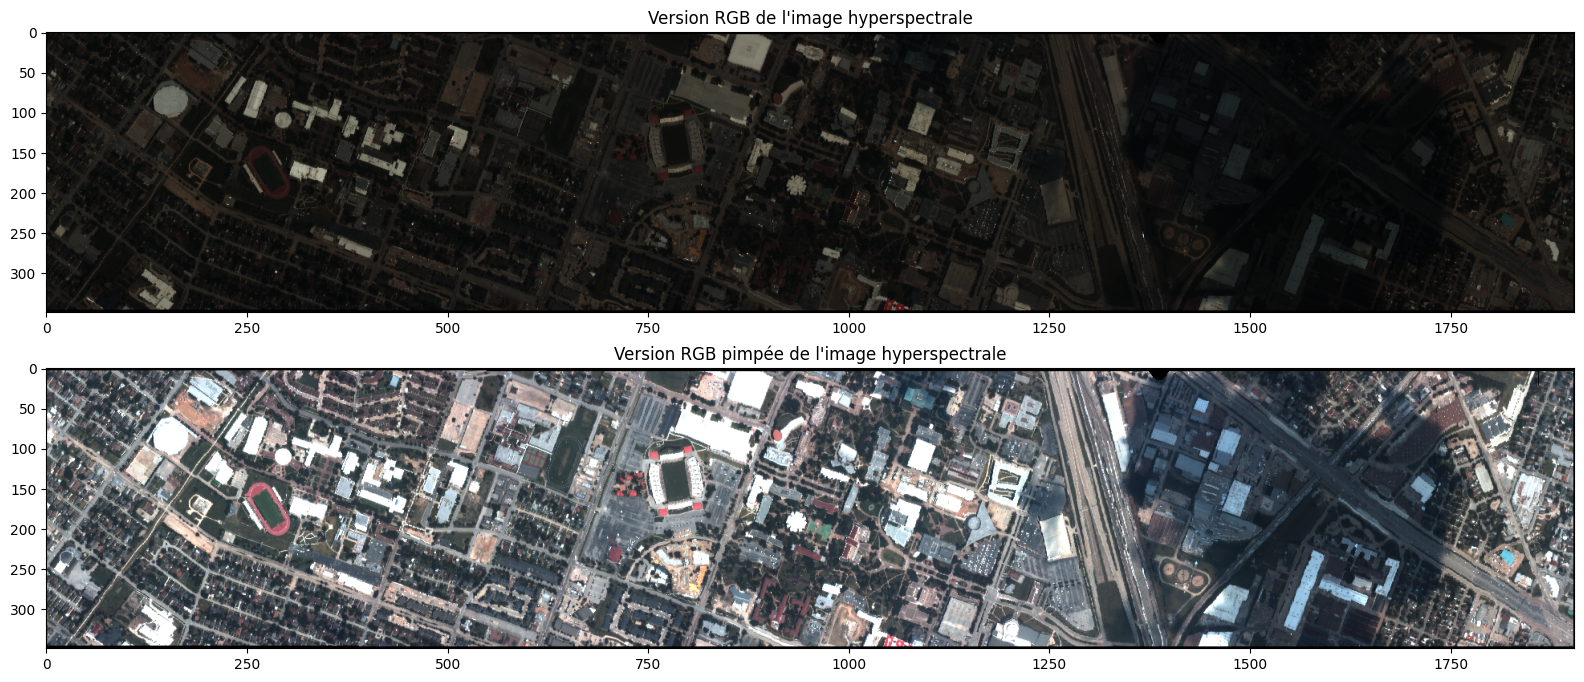

In [84]:
plt.figure(figsize=(20,8))
plt.subplot(211)
plt.title("Version RGB de l'image hyperspectrale")
plt.imshow(hsi_rgb)
plt.subplot(212)
plt.title("Version RGB pimpée de l'image hyperspectrale")
plt.imshow(hsi_rgb_pimped)
plt.show()

La scène est donc composée majoritairement de structures urbaines (maisons, bâtiments, routes, etc). On peut voir également des structures sportives (stade, piste de running, terrains de tennis). La partie droite de l'image est également assombrie par la présence d'un nuage (non discernable dans le LiDAR, qui est insensible aux artefacts d'illumations).

Pour facilier l'analyse visuelle de la scène, on peut la subdiviser en 3 sous-images correspondant à la partie gauche, à la partie centrale et à la partie droite de la scène. On peut remarquer en particulier une bande noire sur le pourtour de l'image hyperspectrale.

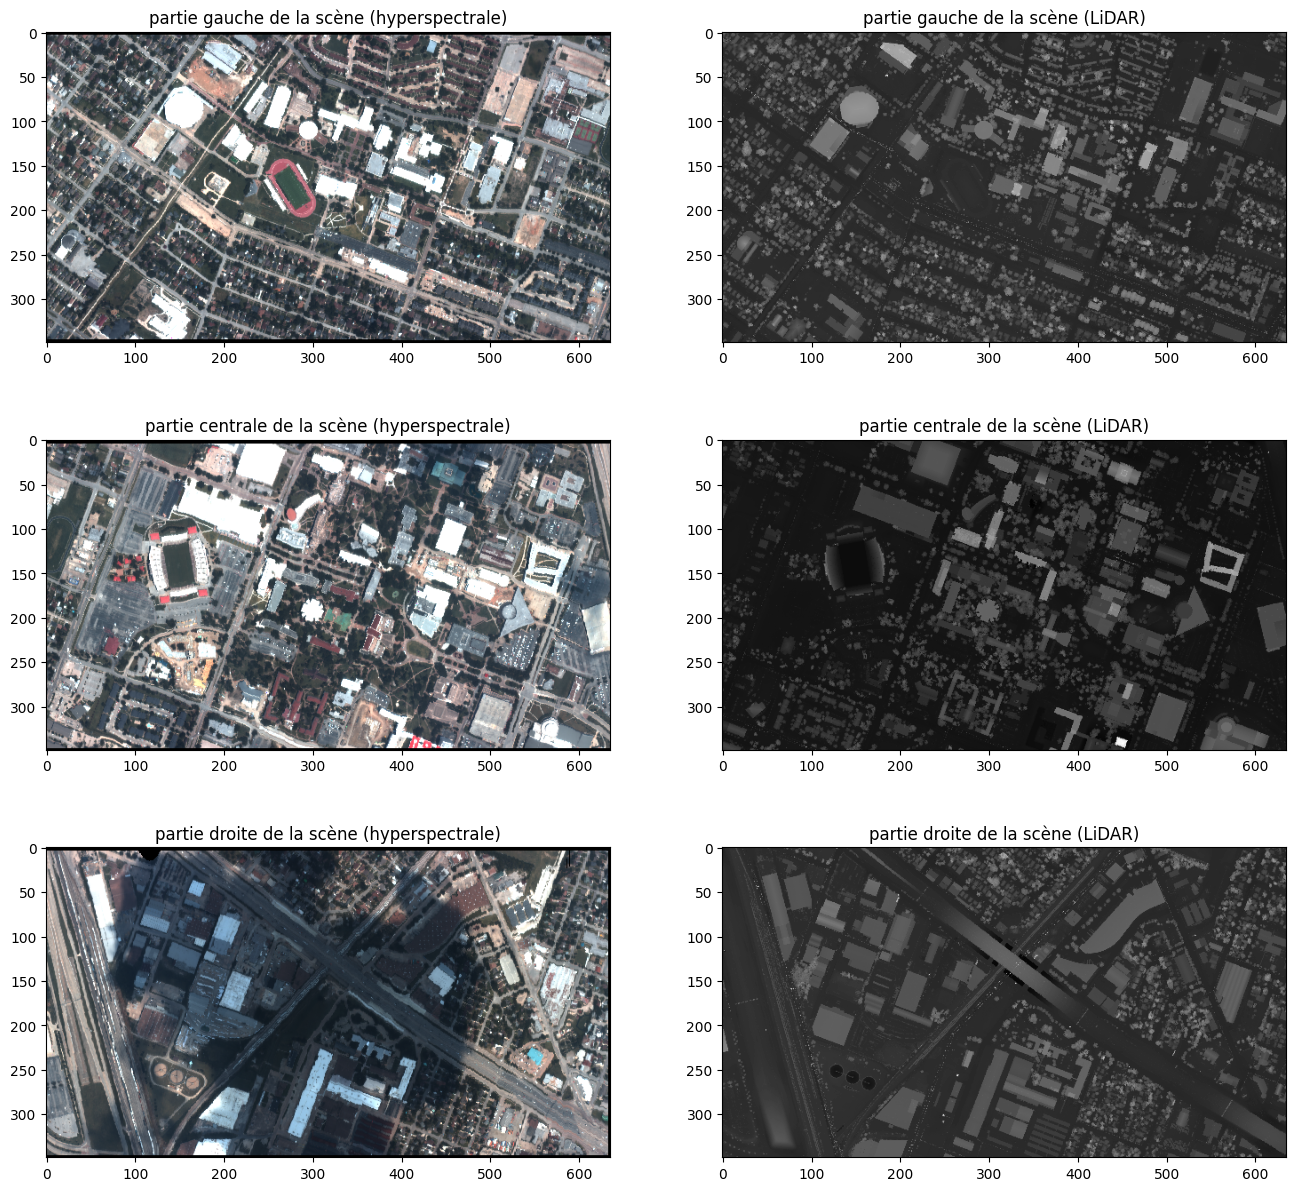

In [85]:
plt.figure(figsize=(16,15))
plt.subplot(321)
plt.title('partie gauche de la scène (hyperspectrale)')
plt.imshow(hsi_rgb_pimped[:,:635,:])
plt.subplot(322)
plt.title('partie gauche de la scène (LiDAR)')
plt.imshow(lidar[:,:635],cmap='gray')
plt.subplot(323)
plt.title('partie centrale de la scène (hyperspectrale)')
plt.imshow(hsi_rgb_pimped[:,635:1270,:])
plt.subplot(324)
plt.title('partie centrale de la scène (LiDAR)')
plt.imshow(lidar[:,635:1270],cmap='gray')
plt.subplot(325)
plt.title('partie droite de la scène (hyperspectrale)')
plt.imshow(hsi_rgb_pimped[:,1270:,:])
plt.subplot(326)
plt.title('partie droite de la scène (LiDAR)')
plt.imshow(lidar[:,1270:],cmap='gray')
plt.show()

## Chargement de la vérité terrain

Dans la scène présentée ci-dessus, 15 classes sémantiques ont été définies par les organisateurs du _Data Fusion Contest 2013_, et des zones au sol correspondant à ces différentes classes ont été identifées. Ces différentes zones de références constituent la vérité terrain, dont une partie vous est fournie dans le cadre du projet (la partie manquante, qui vous est cachée, servira de base de test pour la validation de votre solution).

In [86]:
%%bash
if [ -d "groundtruth" ]; then
    echo "Le dossier groundtruth existe déjà"
else
    mkdir -p "groundtruth"
    wget -q "https://www.lrde.epita.fr/~gtochon/IML/groundtruth.zip" -P "groundtruth"
    unzip -q "groundtruth/*.zip" -d "groundtruth"
    rm "groundtruth/"*.zip*
fi

Le dossier groundtruth existe déjà


In [87]:
groundtruth = np.load('groundtruth/groundtruth.npy')
groundtruth_info = np.load('groundtruth/groundtruth_info.npy',allow_pickle=True)
groundtruth_rgb = plt.imread('groundtruth/groundtruth.png')

La vérité terrain qui vous est fournie dans le cadre du projet est composée de trois fichiers : 
* `groundtruth_info` : un récapitulatif des différentes classes sémantiques (numérotées de 1 à 15) 

In [88]:
groundtruth_info

array([{'class_name': 'grass_healthy', 'class_label': 1, 'class_color': array([  0, 205,   0])},
       {'class_name': 'grass_stressed', 'class_label': 2, 'class_color': array([127, 255,   0])},
       {'class_name': 'grass_synthetic', 'class_label': 3, 'class_color': array([ 46, 205,  87])},
       {'class_name': 'tree', 'class_label': 4, 'class_color': array([  0, 139,   0])},
       {'class_name': 'soil', 'class_label': 5, 'class_color': array([160,  82,  45])},
       {'class_name': 'water', 'class_label': 6, 'class_color': array([  0, 255, 255])},
       {'class_name': 'residential', 'class_label': 7, 'class_color': array([255, 255, 255])},
       {'class_name': 'commercial', 'class_label': 8, 'class_color': array([216, 191, 216])},
       {'class_name': 'road', 'class_label': 9, 'class_color': array([255,   0,   0])},
       {'class_name': 'highway', 'class_label': 10, 'class_color': array([139,   0,   0])},
       {'class_name': 'railway', 'class_label': 11, 'class_color': array

Chaque classe est composée d'environ $190$ pixels (ce qui est peu...)

In [89]:
for ii in range(15):
    print("Classe %d : %s (%d pixels au total)"%(ii+1,groundtruth_info[ii]['class_name'],(groundtruth==ii+1).sum()))

Classe 1 : grass_healthy (198 pixels au total)
Classe 2 : grass_stressed (190 pixels au total)
Classe 3 : grass_synthetic (192 pixels au total)
Classe 4 : tree (188 pixels au total)
Classe 5 : soil (186 pixels au total)
Classe 6 : water (182 pixels au total)
Classe 7 : residential (196 pixels au total)
Classe 8 : commercial (191 pixels au total)
Classe 9 : road (193 pixels au total)
Classe 10 : highway (191 pixels au total)
Classe 11 : railway (181 pixels au total)
Classe 12 : parking_lot1 (192 pixels au total)
Classe 13 : parking_lot2 (184 pixels au total)
Classe 14 : tennis_court (181 pixels au total)
Classe 15 : running_track (187 pixels au total)


* `groundtruth` : la position spatiale dans la scène des différents pixels appartenant à ces 15 classes thématiques. Chaque pixel appartenant à la i$^e$ classe est donc de valeur $i$ dans cette carte de vérité terrain (par convention, tous les pixels dont la classe est inconnue sont de valeur $0$).

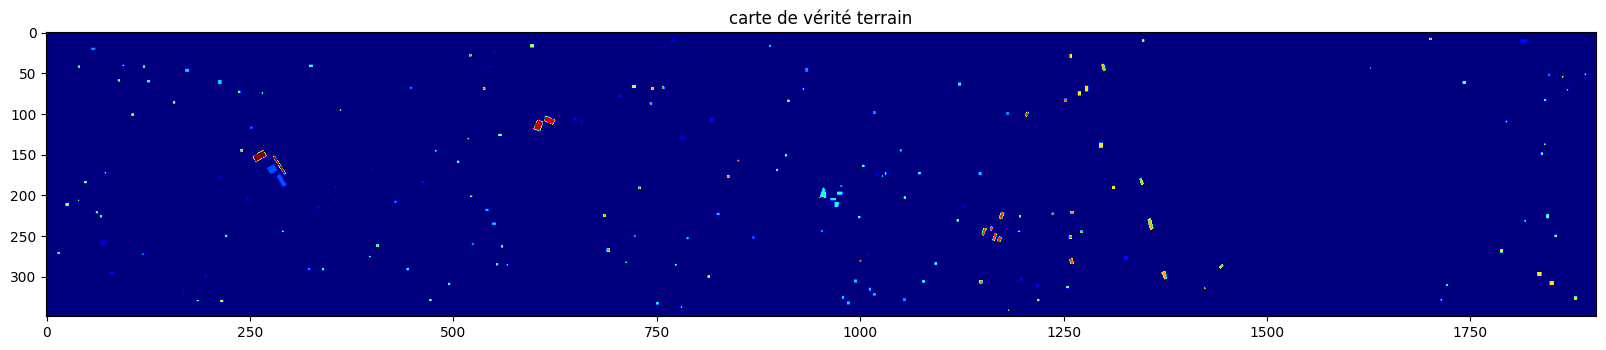

In [90]:
plt.figure(figsize=(20,5))
plt.title('carte de vérité terrain')
plt.imshow(groundtruth, cmap='jet')
plt.show()

* `groundtruth.png` : pour faciliter la visualisation des différentes classes composant la vérité terrain, on peut également attribuer à chaque classe une couleur (arbitraire), et représenter la vérité terrain comme une image RGB.

In [91]:
cls_rgb = []
for ii in groundtruth_info:
    cls_rgb.append(ii['class_color'])
cls_rgb = np.array(cls_rgb).reshape(15,-1,3)

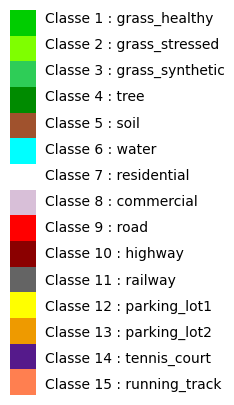

In [92]:
plt.figure(figsize=(5,5))
plt.imshow(cls_rgb)
plt.axis('off')
for cls in range(15):
        plt.text(0.85,1.02*cls,'Classe %d : %s'%(cls+1,groundtruth_info[cls]['class_name']))
plt.show()

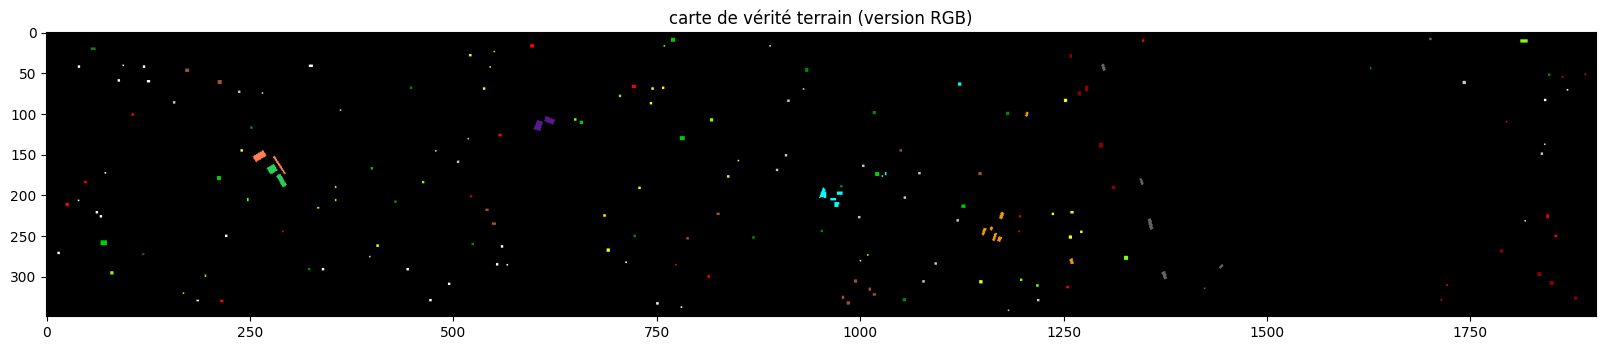

In [93]:
plt.figure(figsize=(20,5))
plt.title('carte de vérité terrain (version RGB)')
plt.imshow(groundtruth_rgb)
plt.show()

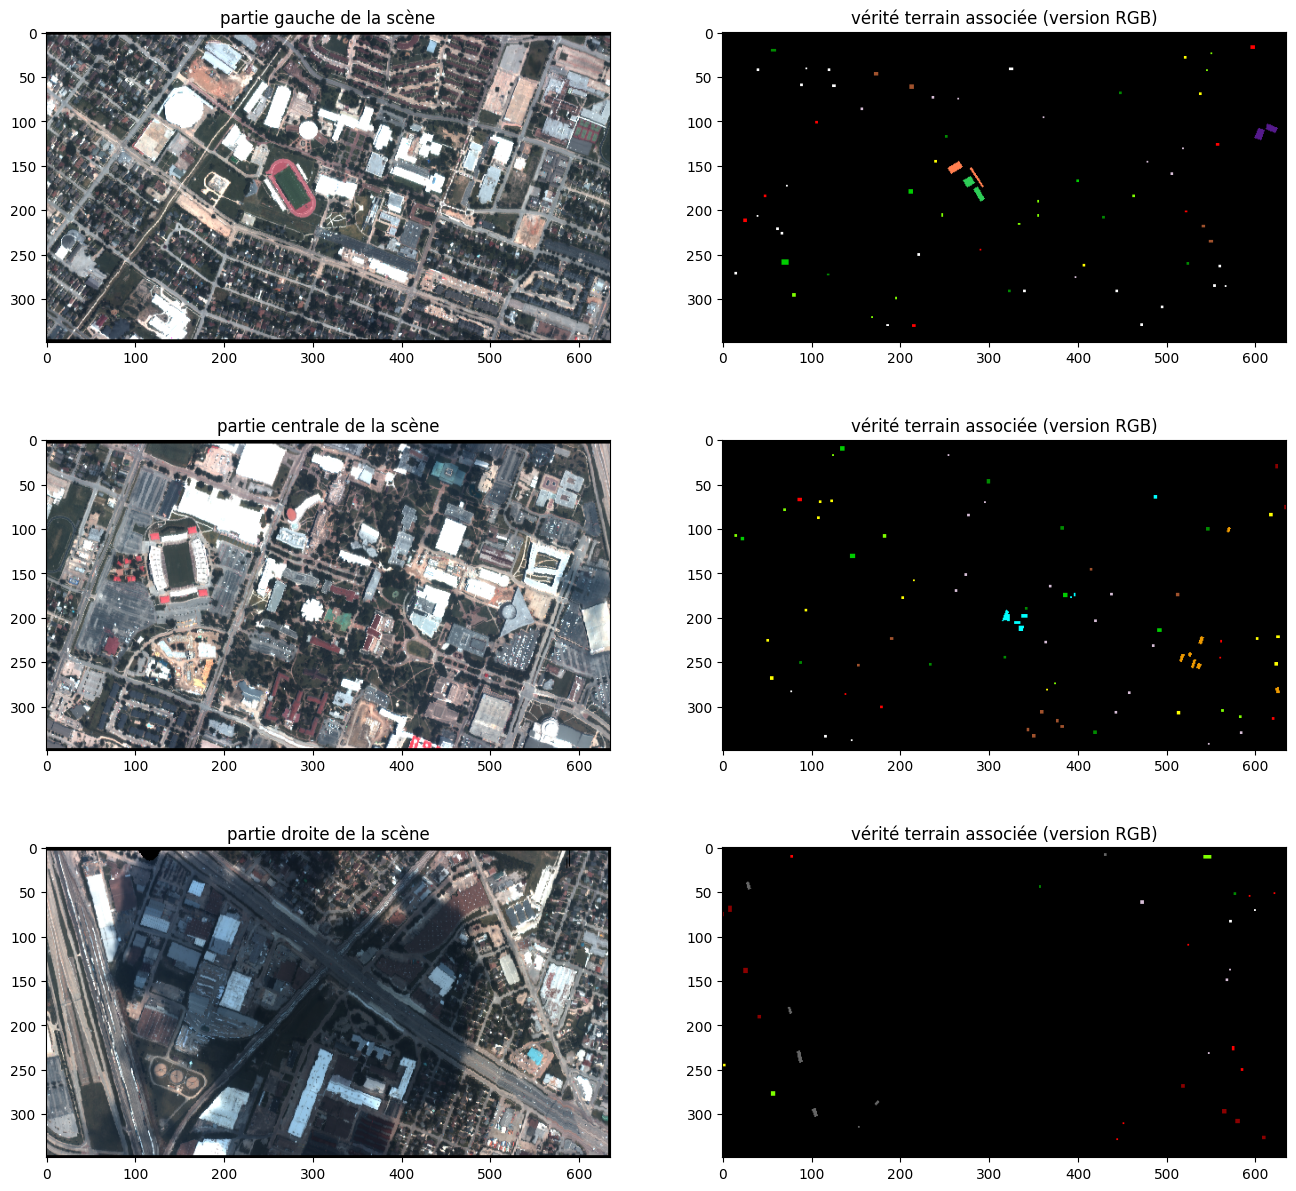

In [94]:
plt.figure(figsize=(16,15))
plt.subplot(321)
plt.title('partie gauche de la scène')
plt.imshow(hsi_rgb_pimped[:,:635,:])
plt.subplot(322)
plt.title('vérité terrain associée (version RGB)')
plt.imshow(groundtruth_rgb[:,:635,:],cmap='gray')
plt.subplot(323)
plt.title('partie centrale de la scène')
plt.imshow(hsi_rgb_pimped[:,635:1270,:])
plt.subplot(324)
plt.title('vérité terrain associée (version RGB)')
plt.imshow(groundtruth_rgb[:,635:1270,:],cmap='gray')
plt.subplot(325)
plt.title('partie droite de la scène')
plt.imshow(hsi_rgb_pimped[:,1270:,:])
plt.subplot(326)
plt.title('vérité terrain associée (version RGB)')
plt.imshow(groundtruth_rgb[:,1270:,:],cmap='gray')
plt.show()

## Objectif du projet

L'objectif du projet est d'effectuer **la classification sémantique des pixels de la scène**, c'est-à-dire assigner à chaque pixel l'identifiant (entre 1 et 15) de la classe à laquelle il appartient. Par exemple, tous les pixels de maison doivent être assignés à la classe $7$ (`residential`), tous les pixels de route doivent être assignés à la classe $9$ (`road`), etc.

Les images hyperspectrales (réflectance) et LiDAR (hauteur) portent une information complémentaire car de nature physique différente. Deux zones adjacentes dans la scène peuvent avoir des réponses spectrales très proches (par exemple, de la végétation et de l'herbe), mais des hauteurs différentes dans le LiDAR. À l'inverse, deux zones adjacentes peuvent avoir des hauteurs identiques dans l'image LiDAR (par exemple, de l'herbe et de la route) mais des réponses spectrales très différentes. Ainsi, votre solution devra, d'une manière ou d'une autre, fusionner l'information issue de l'image LiDAR avec celle de l'image hyperspectrale.

Votre solution devra prendre en entrée les deux images (hyperspectrale et LiDAR) et produire en sortie une carte de classification thématique, où chaque pixel a pour valeur le numéro de la classe à laquelle il appartient. Vous pouvez vous servir de toutes les ressources disponibles dans les bibliothèques `scikit-learn`, `scikit-image`, `numpy` et `scipy`, ainsi que de vos connaissances en traitement d'image (pour par exemple pré-traiter les données d'une manière ou d'une autre, ou post-traiter le résultat de classification).

Votre notebook devra :

- contenir votre code et toutes les explications qui nous permettront de comprendre et valider votre démarche
- exporter votre prédiction finale sur toute l'image au format `.npy` (voir ci-après) dans le même format que la vérité terrain
- préciser la contribution de chaque membre du groupe.

<u> pro tip </u> : une image hyperspectrale est nativement représentée comme un cube de données de dimensions $r \times c \times N$ où $r$ et $c$ correspondent au nombre de lignes et de colonnes dans l'image, et $N$ est le nombre de canaux, ce qui ne correspond pas au format attendu par la plupart des algorithmes de `scikit-image` ($N_{samples} \times N_{features}$, où $N_{samples}$ est le nombre d'échantillons et $N_{features}$ est le nombre de caractéristiques (la dimensionalité) de chaque échantillon). 
<br> Pour transformer une image hyperspectrale au format standard de `scikit-image`, on pourra simplement utiliser `hsi.reshape(rc,N)`

## Export des résultats

Nous vous fournissons ici le code pour exporter vos résultats au bon format.

Il vous suffit d'utiliser la fonction `export_predictions()` ci-dessous, en vous assurant qu'elle ne renvoie pas d'erreurs.

In [95]:
def export_predictions(predictions: np.array, filename: str):
    """
    Exporte les prédictions dans un fichier NPZ.
    :param predictions: np.array de shape (349, 1905) et de dtype uint8 contenant les prédictions
    :param filename: nom du fichier de sortie
    """
    # Check we have the right shape and dtype
    if predictions.shape != (349, 1905):
        raise ValueError("Les prédictions doivent être de shape (349, 1905)")
    if predictions.dtype != np.uint8:
        raise ValueError("Les prédictions doivent être de dtype uint8")
    # Check predictions are in the correct domain
    if np.any(predictions > 15):
        raise ValueError("Les prédictions doivent être dans l'intervalle [0, 15]")
    # Ensure the output file has the right extension
    if not filename.endswith('.npz'):
        filename += '.npz'
    # Save the predictions
    np.savez_compressed(filename, predictions=predictions)
    # Remind students to submit the file
    print(f"Prédictions exportées dans {filename}, n'oubliez pas d'envoyer votre fichier !")   

In [96]:
# Exemples d'exports
predictions_random = np.random.randint(0, 16, size=(349, 1905), dtype=np.uint8)
export_predictions(predictions_random, "predictions_random.npz")

predictions_ones = np.ones((349, 1905), dtype=np.uint8)
export_predictions(predictions_ones, "predictions_ones.npz")

predictions_gt = groundtruth
export_predictions(predictions_gt, "predictions_groundtruth.npz")

Prédictions exportées dans predictions_random.npz, n'oubliez pas d'envoyer votre fichier !
Prédictions exportées dans predictions_ones.npz, n'oubliez pas d'envoyer votre fichier !
Prédictions exportées dans predictions_groundtruth.npz, n'oubliez pas d'envoyer votre fichier !


Voici également une fonction qui vous permet d'évaluer la performance de votre approche par rapport à une cible attendue.
Dans votre cas, vous n'aurez pas accès à la vérité terrain sur le jeu de test mais :
- vous pouvez (devez ?) tester la performance de votre approche sur le jeu d'entraînement (et sur d'éventuels jeux de validation que vous pourriez définir)
- vous avez accès au code d'évaluation que nous utiliserons pour évaluer la performance de votre approche

In [97]:
def eval_performance_raw(predictions: np.array, targets: np.array):
    """Evalue la performance de l'algorithme de classification.

    Args:
        predictions (np.array): prédictions
        targets (np.array): valeurs attendues (vérité terrain)
    """
    # Check we have the right shape and dtype
    if predictions.shape != (349, 1905):
        raise ValueError("Les prédictions doivent être de shape (349, 1905)")
    if predictions.dtype != np.uint8:
        raise ValueError("Les prédictions doivent être de dtype uint8")
    if targets.shape != (349, 1905):
        raise ValueError("Les cibles doivent être de shape (349, 1905)")
    if targets.dtype != np.uint8:
        raise ValueError("Les cibles doivent être de dtype uint8")
    # Check predictions are in the correct domain
    if np.any(predictions > 15):
        raise ValueError("Les prédictions doivent être dans l'intervalle [0, 15]")
    if np.any(targets > 15):
        raise ValueError("Les cibles doivent être dans l'intervalle [0, 15]")
    # Compute the confusion matrix
    confusion_matrix = np.zeros((16, 16), dtype=np.int32)
    for i in range(16):
        for j in range(16):
            confusion_matrix[i, j] = np.sum((predictions == i) & (targets == j))
    # Compute the overall accuracy
    accuracy = np.sum(np.diag(confusion_matrix)) / np.sum(confusion_matrix)
    # Compute the class-wise accuracy
    class_accuracy = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
    # Accuracy ignoring the unclassified pixels in the ground truth
    mask = targets != 0
    accuracy_no_unclassified = np.sum(predictions[mask] == targets[mask]) / np.sum(mask)
    # Return the results
    return accuracy, class_accuracy, accuracy_no_unclassified, confusion_matrix

In [98]:
def load_eval_perf(filename: str, targets: np.array):
    """
    Charge les prédictions depuis un fichier NPZ et évalue la performance de l'algorithme de classification.

    Args:
        filename (str): nom du fichier NPZ contenant les prédictions
        targets (np.array): valeurs attendues (vérité terrain)
    """
    # Load the predictions
    predictions = np.load(filename)['predictions']
    # Evaluate the performance
    return eval_performance_raw(predictions, targets)

Évaluation de predictions_groundtruth.npz:
Mean accuracy (micro, no background): 1.00
Mean accuracy (macro, no background): 1.00


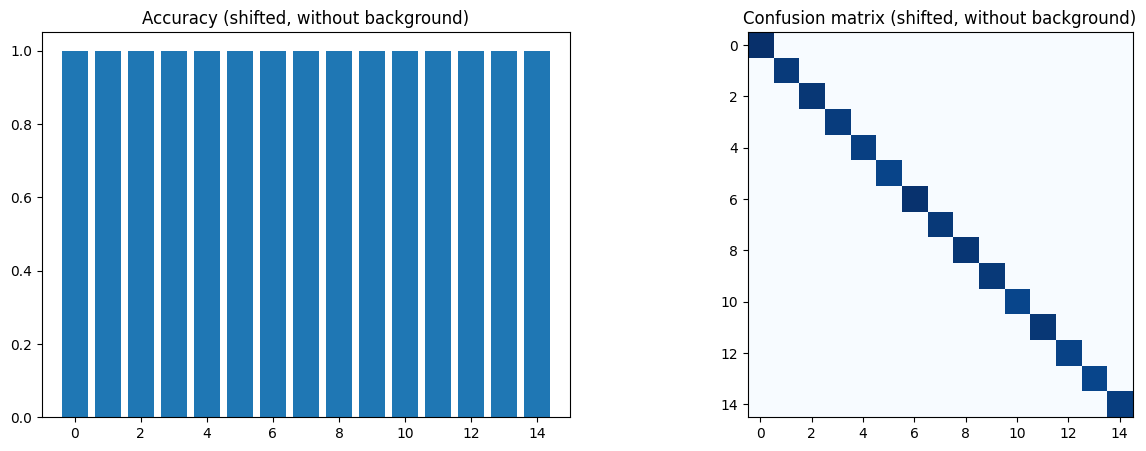

Évaluation de predictions_ones.npz:
Mean accuracy (micro, no background): 0.07
Mean accuracy (macro, no background): nan


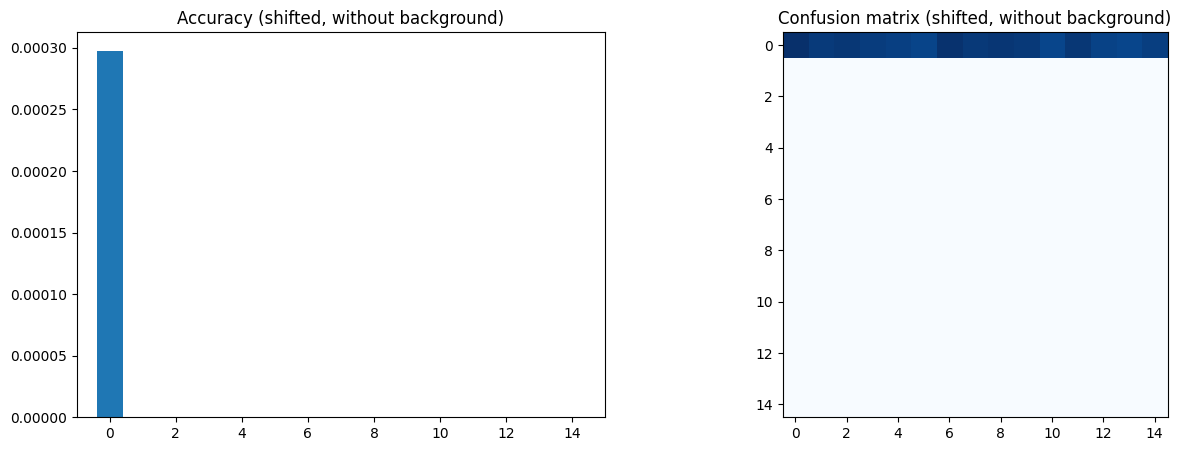

Évaluation de predictions_random.npz:
Mean accuracy (micro, no background): 0.06
Mean accuracy (macro, no background): 0.00


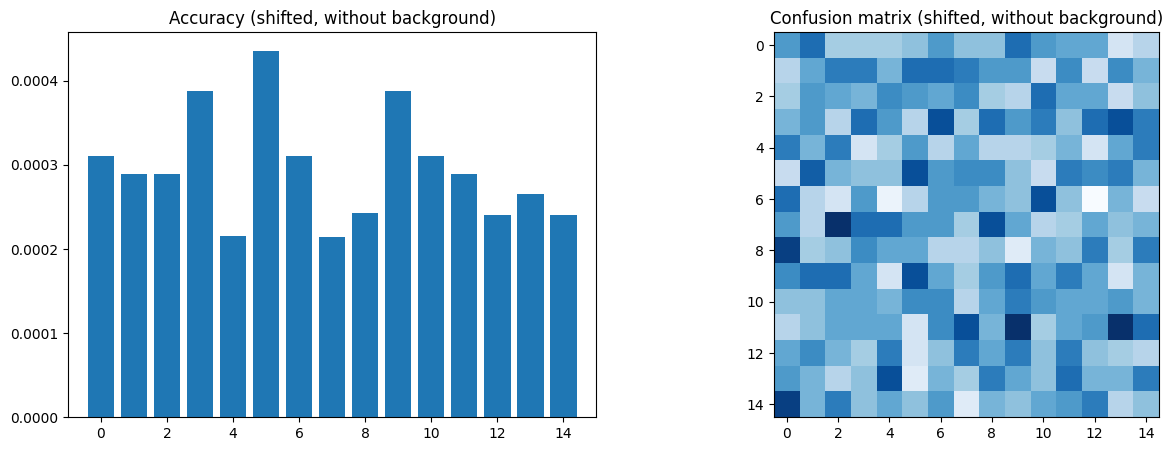

In [99]:
# Exemples d'évaluation
import glob
prediction_files = glob.glob("predictions_*.npz")
groundtruth = np.load('groundtruth/groundtruth.npy')
for file in prediction_files:
    print(f"Évaluation de {file}:")
    accuracy, class_accuracy, accuracy_no_unclassified_micro, confusion_matrix = load_eval_perf(file, groundtruth)
    print(f"Mean accuracy (micro, no background): {accuracy_no_unclassified_micro:.2f}")
    accuracy_no_unclassified_macro = np.mean(class_accuracy[1:])
    print(f"Mean accuracy (macro, no background): {accuracy_no_unclassified_macro:.2f}")
    # Display results
    plt.figure(figsize=(15,5))
    plt.subplot(121)
    plt.title('Accuracy (shifted, without background)')
    plt.bar(range(15), class_accuracy[1:])
    plt.xlim(-1, 15)
    plt.subplot(122)
    plt.title('Confusion matrix (shifted, without background)')
    plt.imshow(confusion_matrix[1:,1:], cmap='Blues')
    plt.show()


# À vous de jouer !

In [100]:
def load_learn_data(img_hsi, img_lidar):
    groundtruth = np.load('groundtruth/groundtruth.npy')
    
    # boolean mask of valid locations
    mask = groundtruth > 0

    # Get indices where mask is True
    rows, cols = np.where(mask)
    
    # Get groundtruth values for valid positions
    known_outputs = groundtruth[rows, cols].tolist()

    # Get HSI and LiDAR values at those positions
    known_inputs = []
    for i in range(len(rows)):
        hsi_values = img_hsi[rows[i], cols[i], :]
        lidar_values = img_lidar[rows[i], cols[i]]

        # Concatenate HSI and LiDAR values for each position
        known_inputs.append(hsi_values)

    return np.array(known_inputs), np.array(known_outputs)

In [120]:
def load_learn_data_multi_source(img_hsi, img_lidar):
    groundtruth = np.load('groundtruth/groundtruth.npy')
    
    # boolean mask of valid locations
    mask = groundtruth > 0

    # Get indices where mask is True
    rows, cols = np.where(mask)
    
    # Get groundtruth values for valid positions
    known_outputs = groundtruth[rows, cols].tolist()
    
    # Extract features from images
    known_inputs_hsi = []
    known_inputs_lidar = []
    
    for i in range(len(rows)):
        # Extract HSI features
        hsi_features = img_hsi[rows[i], cols[i], :]
        known_inputs_hsi.append(hsi_features)
        
        # Extract LiDAR feature
        lidar_feature = img_lidar[rows[i], cols[i]]
        known_inputs_lidar.append([lidar_feature])  # Make it a 2D array
    
    return np.array(known_inputs_hsi), np.array(known_inputs_lidar), known_outputs

In [114]:
custom_colors = [
    [0, 0, 0],           # Class 0 - Black (Background)
    [1, 0, 0],           # Class 1 - Red
    [0, 1, 0],           # Class 2 - Green
    [0, 0, 1],           # Class 3 - Blue
    [1, 1, 0],           # Class 4 - Yellow
    [1, 0, 1],           # Class 5 - Magenta
    [0, 1, 1],           # Class 6 - Cyan
    [0.5, 0, 0],         # Class 7 - Dark Red
    [0, 0.5, 0],         # Class 8 - Dark Green
    [0, 0, 0.5],         # Class 9 - Dark Blue
    [0.5, 0.5, 0],       # Class 10 - Olive
    [0.5, 0, 0.5],       # Class 11 - Purple
    [0, 0.5, 0.5],       # Class 12 - Teal
    [0.7, 0.7, 0.7],     # Class 13 - Light Gray
    [1, 0.5, 0],         # Class 14 - Orange
    [0.5, 1, 0],         # Class 15 - Lime
    [1, 1, 1],           # Class 16 - White
]

In [103]:
def visualize_predictions(predictions, custom_colors):
    # Create a colormap for visualization
    num_classes = np.max(predictions) + 1
    
    # Pad the custom colors if we have more classes than defined colors
    if num_classes > len(custom_colors):
        # Add random colors for any additional classes
        for i in range(len(custom_colors), num_classes):
            custom_colors.append(np.random.rand(3))
    
    # Create RGB image from predictions
    height, width = predictions.shape
    rgb_image = np.zeros((height, width, 3))
    
    # Map each class to its color
    for i in range(num_classes):
        mask = (predictions == i)
        rgb_image[mask] = custom_colors[i]
    
    # Display the predictions
    plt.figure(figsize=(12, 10))
    plt.imshow(rgb_image)
    plt.title('Prediction Results')
    
    # Add a colorbar with class labels
    legend_patches = [plt.Rectangle((0, 0), 1, 1, color=custom_colors[i]) for i in range(num_classes)]
    plt.legend(legend_patches, [f'Class {i}' for i in range(num_classes)], 
               loc='upper right', bbox_to_anchor=(1.3, 1))
    
    plt.tight_layout()
    plt.show()
    
    # Also create and display a more detailed figure with class distribution
    plt.figure(figsize=(15, 5))
    
    # Plot prediction image
    plt.subplot(121)
    plt.imshow(rgb_image)
    plt.title('Prediction Map')
    plt.axis('off')
    
    # Plot class distribution
    plt.subplot(122)
    class_counts = np.bincount(predictions.flatten(), minlength=num_classes)
    plt.bar(range(num_classes), class_counts, color=custom_colors[:num_classes])
    plt.title('Class Distribution')
    plt.xlabel('Class')
    plt.ylabel('Pixel Count')
    plt.grid(axis='y', alpha=0.3)
    
    # Add percentage labels on the bars
    total_pixels = predictions.size
    for i, count in enumerate(class_counts):
        percentage = (count / total_pixels) * 100
        if percentage > 1:  # Only show labels for classes with significant presence
            plt.text(i, count + (max(class_counts) * 0.01), 
                     f'{percentage:.1f}%', 
                     ha='center', va='bottom', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    return rgb_image

In [138]:
def visualize_multi_source_predictions(predictions_dict, custom_colors):
    # Get only the needed prediction types
    filtered_dict = {k: v for k, v in predictions_dict.items() if k in ['hsi', 'lidar', 'ensemble']}
    
    # Create a colormap for visualization
    max_class = max(np.max(pred) for pred in filtered_dict.values()) + 1
    
    # Pad the custom colors if needed
    if max_class > len(custom_colors):
        for i in range(len(custom_colors), max_class):
            custom_colors.append(np.random.rand(3))
    
    # Create a figure with subplots for each prediction source (1x3 layout)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Extract one prediction to get dimensions
    sample_pred = next(iter(filtered_dict.values()))
    height, width = sample_pred.shape
    
    for idx, (source, predictions) in enumerate(filtered_dict.items()):
        rgb_image = np.zeros((height, width, 3))
        
        # Map each class to its color
        for i in range(max_class):
            mask = (predictions == i)
            rgb_image[mask] = custom_colors[i]
        
        # Display the predictions
        axes[idx].imshow(rgb_image)
        axes[idx].set_title(f'{source.capitalize()} Predictions')
        axes[idx].axis('off')
    
    # Add a colorbar with class labels
    legend_patches = [plt.Rectangle((0, 0), 1, 1, color=custom_colors[i]) for i in range(max_class)]
    fig.legend(legend_patches, [f'Class {i}' for i in range(max_class)], 
               loc='center right', bbox_to_anchor=(1.13, 0.5))
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    plt.show()
    
    # Also create comparison figure showing differences between models
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Compare HSI vs LiDAR
    diff_hsi_lidar = (filtered_dict['hsi'] != filtered_dict['lidar'])
    diff_img = np.zeros((height, width, 3))
    diff_img[diff_hsi_lidar] = [1, 0, 0]  # Red for differences
    axes[0].imshow(diff_img)
    axes[0].set_title('Differences: HSI vs LiDAR')
    axes[0].axis('off')
    agreement = 100 * (1 - np.mean(diff_hsi_lidar))
    axes[0].text(width//2, height-10, f"Agreement: {agreement:.1f}%", 
                 ha='center', color='white', fontsize=12, 
                 bbox=dict(facecolor='black', alpha=0.7))
    
    # Compare HSI vs Ensemble
    diff_hsi_ensemble = (filtered_dict['hsi'] != filtered_dict['ensemble'])
    diff_img = np.zeros((height, width, 3))
    diff_img[diff_hsi_ensemble] = [1, 0, 0]
    axes[1].imshow(diff_img)
    axes[1].set_title('Differences: HSI vs Ensemble')
    axes[1].axis('off')
    agreement = 100 * (1 - np.mean(diff_hsi_ensemble))
    axes[1].text(width//2, height-10, f"Agreement: {agreement:.1f}%", 
                 ha='center', color='white', fontsize=12, 
                 bbox=dict(facecolor='black', alpha=0.7))
    
    # Compare LiDAR vs Ensemble
    diff_lidar_ensemble = (filtered_dict['lidar'] != filtered_dict['ensemble'])
    diff_img = np.zeros((height, width, 3))
    diff_img[diff_lidar_ensemble] = [1, 0, 0]
    axes[2].imshow(diff_img)
    axes[2].set_title('Differences: LiDAR vs Ensemble')
    axes[2].axis('off')
    agreement = 100 * (1 - np.mean(diff_lidar_ensemble))
    axes[2].text(width//2, height-10, f"Agreement: {agreement:.1f}%", 
                 ha='center', color='white', fontsize=12, 
                 bbox=dict(facecolor='black', alpha=0.7))
    
    plt.tight_layout()
    plt.show()
    
    # Create a figure showing class distribution for each model
    plt.figure(figsize=(15, 6))
    
    # Get class counts for each model
    for idx, (source, predictions) in enumerate(filtered_dict.items()):
        class_counts = np.bincount(predictions.flatten(), minlength=max_class)
        plt.subplot(1, 3, idx+1)
        plt.bar(range(max_class), class_counts, color=custom_colors[:max_class])
        plt.title(f'{source.capitalize()} Class Distribution')
        plt.xlabel('Class')
        plt.ylabel('Pixel Count')
        plt.grid(axis='y', alpha=0.3)
        
        # Add percentage labels on the bars
        total_pixels = predictions.size
        for i, count in enumerate(class_counts):
            percentage = (count / total_pixels) * 100
            if percentage > 2:  # Only show labels for classes with significant presence
                plt.text(i, count + (max(class_counts) * 0.01), 
                        f'{percentage:.1f}%', 
                        ha='center', va='bottom', rotation=0, fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [105]:
def classifier_multidata(img_hsi, img_lidar, known_inputs, known_outputs):
    print('Starting classifier...')
    model_path = "saved_rfc_model.pkl"
    img_height, img_width, n_bands = img_hsi.shape
    
    print(f"HSI shape: {img_hsi.shape}, LIDAR shape: {img_lidar.shape}")
    print(f"Known inputs shape: {known_inputs.shape}, Known outputs shape: {known_outputs.shape}")
    
    input_train, input_test, output_train, output_test = train_test_split(
        known_inputs, 
        known_outputs, 
        test_size=0.2,
        random_state=42,
        stratify=known_outputs
    )
    
    # Create pipeline with verbose classifier
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1))
    ])
    
    # Load or train model
    if os.path.exists(model_path):
        print(f"🔁 Loading model from {model_path}...")
        with open(model_path, "rb") as f:
            pipeline = pickle.load(f)
    else:
        print("🛠️ Training model...")
        pipeline.fit(input_train, output_train)
        with open(model_path, "wb") as f:
            pickle.dump(pipeline, f)
        print(f"✅ Model saved to {model_path}")
    
    # Evaluate on test set
    print('Testing model...')
    test_predictions = pipeline.predict(input_test)
    accuracy = accuracy_score(output_test, test_predictions)
    print(f"Test Accuracy: {accuracy:.4f}")
    print(classification_report(output_test, test_predictions))
    
    # Batch prediction - ONLY using HSI data (not combining with LIDAR)
    print(f'Predicting full image ({img_height}x{img_width})...')
    
    # Check what features the model was trained with
    n_features_expected = pipeline.named_steps['scaler'].n_features_in_
    print(f"Model expects {n_features_expected} features")
    
    # Reshape HSI data for batch processing
    img_hsi_flat = img_hsi.reshape(-1, n_bands)
    
    # Process in chunks to avoid memory issues
    predictions = np.zeros((img_height, img_width), dtype=np.uint8)
    chunk_size = 50000  # Adjust based on your memory constraints
    total_pixels = img_height * img_width
    
    print(f"Processing {total_pixels} pixels in chunks of {chunk_size}...")
    for i in range(0, total_pixels, chunk_size):
        end_idx = min(i + chunk_size, total_pixels)
        chunk = img_hsi_flat[i:end_idx]
        # Make sure chunk has the right number of features
        if chunk.shape[1] != n_features_expected:
            print(f"Warning: Feature mismatch. Model expects {n_features_expected}, but data has {chunk.shape[1]}")
            # If needed, adjust chunk to match expected features
            if chunk.shape[1] > n_features_expected:
                chunk = chunk[:, :n_features_expected]  # Use only first n_features_expected features
        
        chunk_predictions = pipeline.predict(chunk)
        predictions.flat[i:end_idx] = chunk_predictions
        if (i + chunk_size) % (chunk_size * 10) == 0 or end_idx == total_pixels:
            print(f"Processed {end_idx}/{total_pixels} pixels ({int(end_idx/total_pixels*100)}%)")
    
    print('Prediction completed')
    return predictions

In [127]:
def classifier_singledata(input_data, output_data, model_name, random_state=42):
    model_path = f"saved_{model_name}.pkl"
    
    # Split data
    input_train, input_test, output_train, output_test = train_test_split(
        input_data, 
        output_data, 
        test_size=0.2,
        random_state=random_state,
        stratify=output_data
    )
    
    # Create pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(random_state=random_state, n_jobs=-1))
    ])
    
    # Load or train model
    if os.path.exists(model_path):
        print(f"🔁 Loading model from {model_path}...")
        with open(model_path, "rb") as f:
            pipeline = pickle.load(f)
    else:
        print(f"🛠️ Training {model_name} model...")
        pipeline.fit(input_train, output_train)
        with open(model_path, "wb") as f:
            pickle.dump(pipeline, f)
        print(f"✅ Model saved to {model_path}")
    
    # Evaluate on test set
    print(f'Testing {model_name} model...')
    test_predictions = pipeline.predict(input_test)
    accuracy = accuracy_score(output_test, test_predictions)
    print(f"Test Accuracy: {accuracy:.4f}")
    print(classification_report(output_test, test_predictions))
    
    return pipeline

In [107]:
def predict_with_model(model, input_data, image_shape):
    height, width = image_shape
    total_pixels = height * width
    
    # Process in chunks to avoid memory issues
    predictions = np.zeros(total_pixels, dtype=np.uint8)
    chunk_size = 50000  # Adjust based on your memory constraints
    
    print(f"Processing {total_pixels} pixels in chunks of {chunk_size}...")
    for i in range(0, total_pixels, chunk_size):
        end_idx = min(i + chunk_size, total_pixels)
        chunk = input_data[i:end_idx]
        chunk_predictions = model.predict(chunk)
        predictions[i:end_idx] = chunk_predictions
        
        if (i + chunk_size) % (chunk_size * 10) == 0 or end_idx == total_pixels:
            print(f"Processed {end_idx}/{total_pixels} pixels ({int(end_idx/total_pixels*100)}%)")
    
    return predictions.reshape(height, width)

In [132]:
def classifier_mergedata(img_hsi, img_lidar, known_inputs_hsi, known_inputs_lidar, known_outputs):
    print('Starting multi-source classifier...')
    
    img_height, img_width = img_hsi.shape[0], img_hsi.shape[1]
    n_bands = img_hsi.shape[2]
    
    # Create combined features for training a fusion model
    known_inputs_combined = np.hstack((known_inputs_hsi, known_inputs_lidar))
    
    # Train separate models for each data source
    print('\n--- HSI Model Training ---')
    hsi_model = classifier_singledata(known_inputs_hsi, known_outputs, "hsi_model")
    
    print('\n--- LiDAR Model Training ---')
    lidar_model = classifier_singledata(known_inputs_lidar, known_outputs, "lidar_model")
    
    # Prepare data for prediction
    print('\nPreparing data for prediction...')
    img_hsi_flat = img_hsi.reshape(-1, n_bands)
    img_lidar_flat = img_lidar.reshape(-1, 1)  # Assuming LiDAR has 1 channel
    
    # Make predictions with each model
    print('\n--- HSI Predictions ---')
    hsi_predictions = predict_with_model(hsi_model, img_hsi_flat, (img_height, img_width))
    
    print('\n--- LiDAR Predictions ---')
    lidar_predictions = predict_with_model(lidar_model, img_lidar_flat, (img_height, img_width))
    
    # Create a voting ensemble prediction
    print('\n--- Creating Ensemble Prediction ---')
    ensemble_predictions = np.zeros((img_height, img_width), dtype=np.uint8)
    
    # Simple majority voting ensemble
    for i in range(img_height):
        for j in range(img_width):
            votes = np.array([hsi_predictions[i,j], lidar_predictions[i,j]])
            # Get the most common class (mode)
            unique_values, counts = np.unique(votes, return_counts=True)
            ensemble_predictions[i,j] = unique_values[np.argmax(counts)]
    
    print('All predictions completed')
    
    # Return all predictions for visualization and comparison
    return {
        'hsi': hsi_predictions,
        'lidar': lidar_predictions,
        'ensemble': ensemble_predictions
    }

In [124]:
def pipeline_multidata(export_name, custom_colors):
    # Load images
    print('Loading images...')
    img_hsi = np.load('data/hyperspectral.npy')
    img_lidar = np.load('data/lidar.npy')

    # Load learning data
    print('Loading learning data...')
    known_inputs, known_outputs = load_learn_data(img_hsi, img_lidar)

    # Classifier
    predictions = classifier(img_hsi, img_lidar, known_inputs, known_outputs)

    # Export predictions
    print('Exporting predictions...')
    export_predictions(predictions, 'predictions/predictions_' + export_name)
    
    # Visualize predictions
    print('Visualizing predictions...')
    visualize_predictions(predictions, custom_colors)

    # Compare predictions
    print('Comapring predictions...')
    prediction_files = glob.glob("predictions/predictions_*.npz")
    groundtruth = np.load('groundtruth/groundtruth.npy')
    for file in prediction_files:
        print(f"Évaluation de {file}:")
        accuracy, class_accuracy, accuracy_no_unclassified_micro, confusion_matrix = load_eval_perf(file, groundtruth)
        print(f"Mean accuracy (micro, no background): {accuracy_no_unclassified_micro:.2f}")
        accuracy_no_unclassified_macro = np.mean(class_accuracy[1:])
        print(f"Mean accuracy (macro, no background): {accuracy_no_unclassified_macro:.2f}")
        
        # Display results
        plt.figure(figsize=(15,5))
        plt.subplot(121)
        plt.title('Accuracy (shifted, without background)')
        plt.bar(range(15), class_accuracy[1:])
        plt.xlim(-1, 15)
        plt.subplot(122)
        plt.title('Confusion matrix (shifted, without background)')
        plt.imshow(confusion_matrix[1:,1:], cmap='Blues')
        plt.show()


In [133]:
def pipeline_mergedata(export_name, custom_colors):
    # Load images
    print('Loading images...')
    img_hsi = np.load('data/hyperspectral.npy')
    img_lidar = np.load('data/lidar.npy')
    
    # Load learning data
    print('Loading learning data...')
    known_inputs_hsi, known_inputs_lidar, known_outputs = load_learn_data_multi_source(img_hsi, img_lidar)
    
    # Multi-source classifier
    predictions_dict = classifier_mergedata(img_hsi, img_lidar, known_inputs_hsi, known_inputs_lidar, known_outputs)
    
    # Export predictions
    print('Exporting predictions...')
    for source, predictions in predictions_dict.items():
        export_predictions(predictions, f'predictions/predictions_{export_name}_{source}')
    
    # Visualize predictions
    print('Visualizing predictions...')
    visualize_multi_source_predictions(predictions_dict, custom_colors)
    
    # Compare predictions
    print('Comparing predictions...')
    groundtruth = np.load('groundtruth/groundtruth.npy')
    
    for source, predictions in predictions_dict.items():
        accuracy = np.mean(predictions == groundtruth) * 100
        print(f"{source.capitalize()} model accuracy: {accuracy:.2f}%")
    
    # More detailed evaluation with the combined model (final result)
    file_path = f'predictions/predictions_{export_name}_combined.npz'
    print(f"\nDetailed evaluation of combined model:")
    accuracy, class_accuracy, accuracy_no_unclassified_micro, confusion_matrix = load_eval_perf(file_path, groundtruth)
    print(f"Mean accuracy (micro, no background): {accuracy_no_unclassified_micro:.2f}")
    accuracy_no_unclassified_macro = np.mean(class_accuracy[1:])
    print(f"Mean accuracy (macro, no background): {accuracy_no_unclassified_macro:.2f}")
    
    # Display results
    plt.figure(figsize=(15,5))
    plt.subplot(121)
    plt.title('Accuracy (shifted, without background)')
    plt.bar(range(15), class_accuracy[1:])
    plt.xlim(-1, 15)
    plt.subplot(122)
    plt.title('Confusion matrix (shifted, without background)')
    plt.imshow(confusion_matrix[1:,1:], cmap='Blues')
    plt.show()

Loading images...
Loading learning data...
Starting classifier...
HSI shape: (349, 1905, 144), LIDAR shape: (349, 1905)
Known inputs shape: (2832, 144), Known outputs shape: (2832,)
🔁 Loading model from saved_rfc_model.pkl...
Testing model...
Test Accuracy: 0.8977
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        40
           2       0.97      1.00      0.99        38
           3       1.00      1.00      1.00        39
           4       1.00      1.00      1.00        38
           5       0.90      0.95      0.92        37
           6       1.00      0.97      0.99        36
           7       0.82      0.79      0.81        39
           8       0.89      0.89      0.89        38
           9       0.83      0.77      0.80        39
          10       0.85      0.89      0.87        38
          11       0.78      0.86      0.82        36
          12       0.70      0.77      0.73        39
          13       0.84      0.7

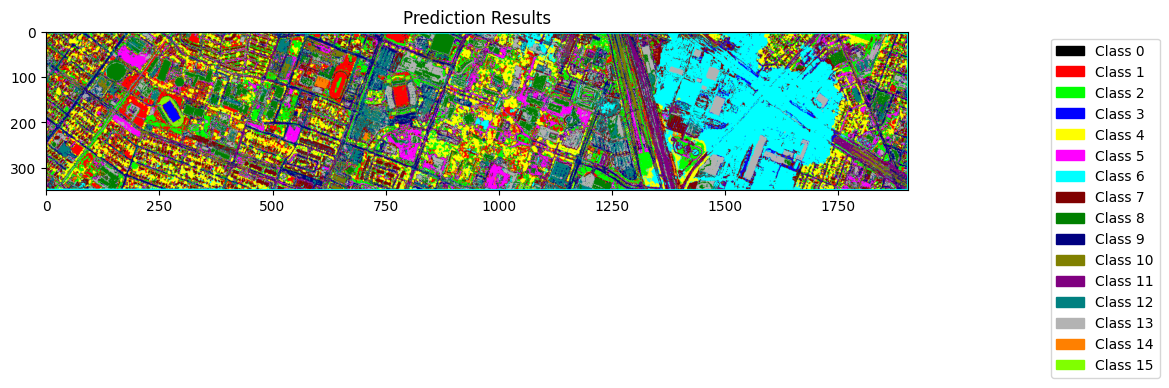

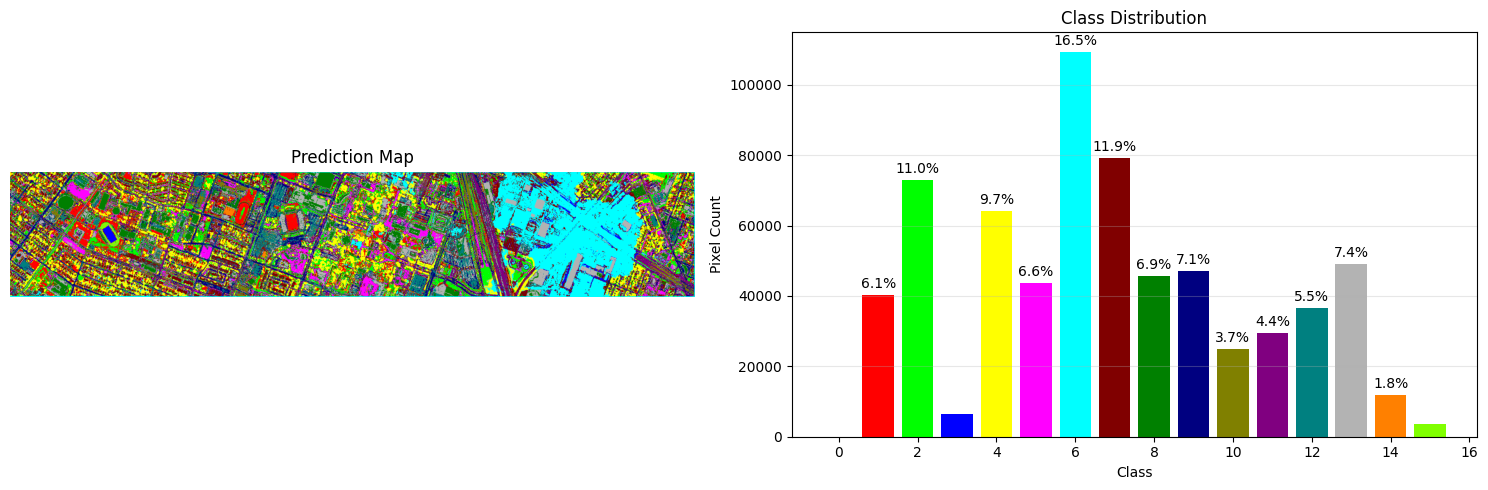

Comapring predictions...
Évaluation de predictions/predictions_random_forest_classifier.npz:
Mean accuracy (micro, no background): 0.98
Mean accuracy (macro, no background): 0.01


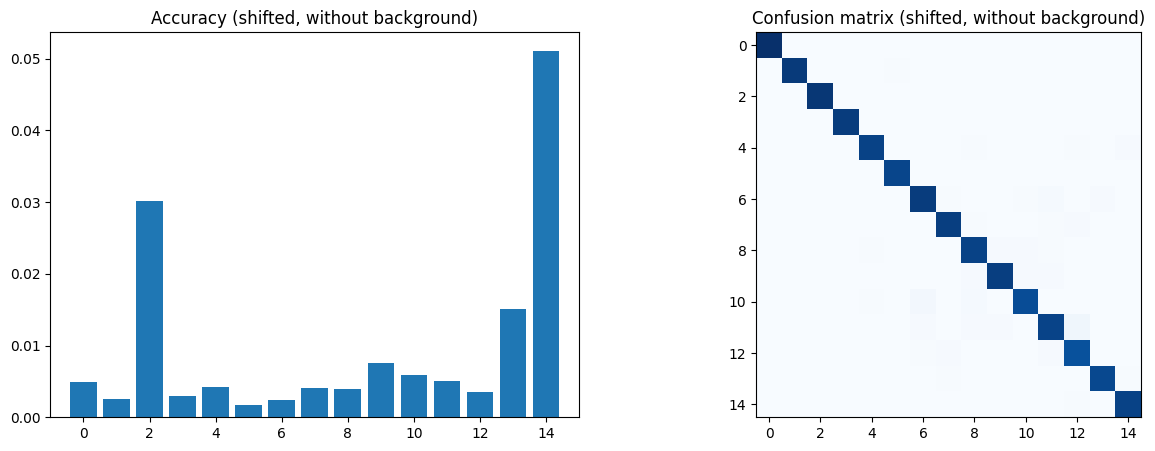

Évaluation de predictions/predictions_random_forest_classifier_multi.npz:
Mean accuracy (micro, no background): 0.98
Mean accuracy (macro, no background): 0.01


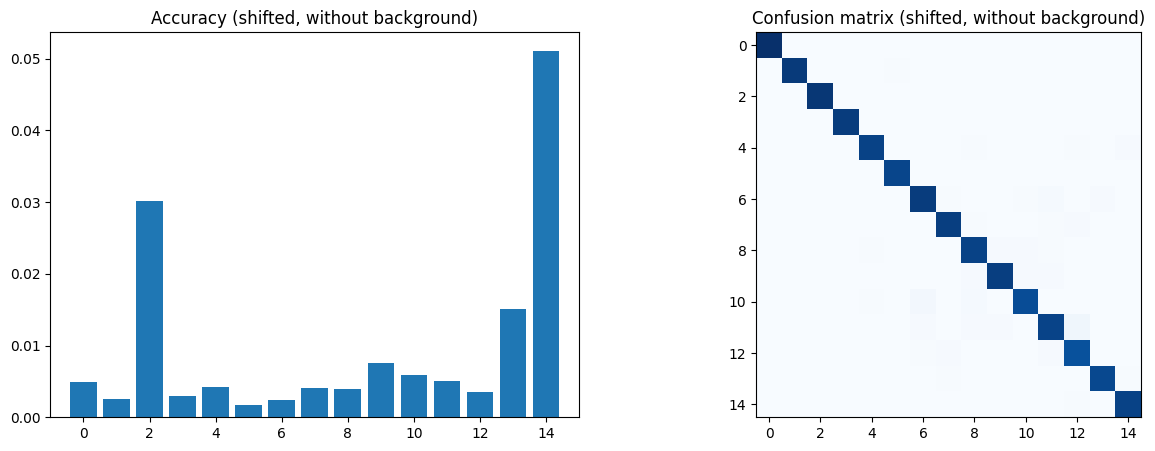

In [115]:
import warnings
warnings.filterwarnings("ignore")
pipeline_multidata("random_forest_classifier_multi", custom_colors)

Loading images...
Loading learning data...
Starting multi-source classifier...

--- HSI Model Training ---
🔁 Loading model from saved_hsi_model.pkl...
Testing hsi_model model...
Test Accuracy: 0.8977
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        40
           2       0.97      1.00      0.99        38
           3       1.00      1.00      1.00        39
           4       1.00      1.00      1.00        38
           5       0.90      0.95      0.92        37
           6       1.00      0.97      0.99        36
           7       0.82      0.79      0.81        39
           8       0.89      0.89      0.89        38
           9       0.83      0.77      0.80        39
          10       0.85      0.89      0.87        38
          11       0.78      0.86      0.82        36
          12       0.70      0.77      0.73        39
          13       0.84      0.70      0.76        37
          14       0.94      0.94      0.94

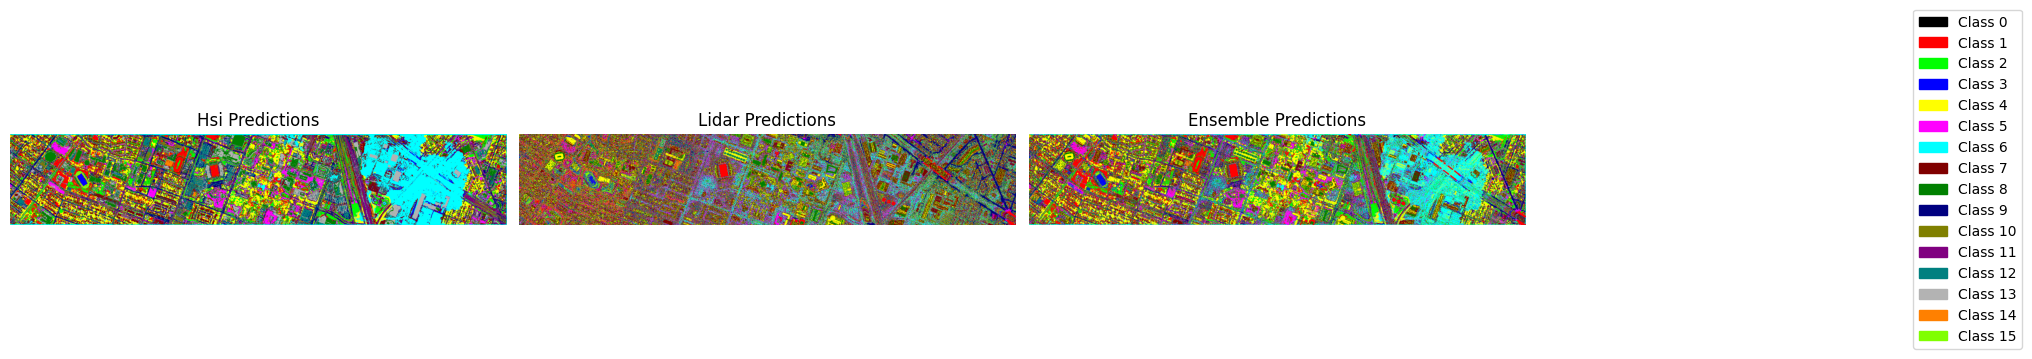

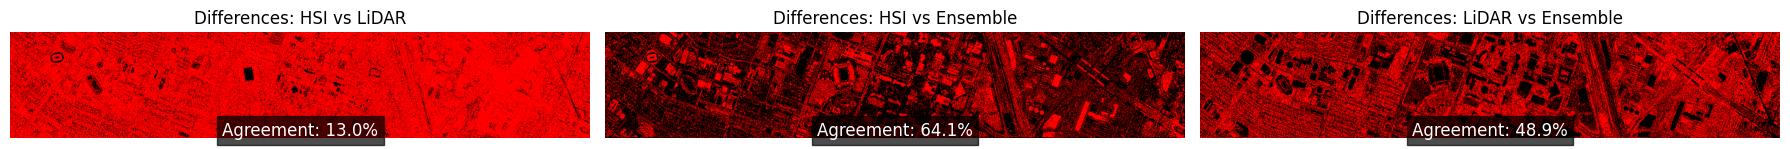

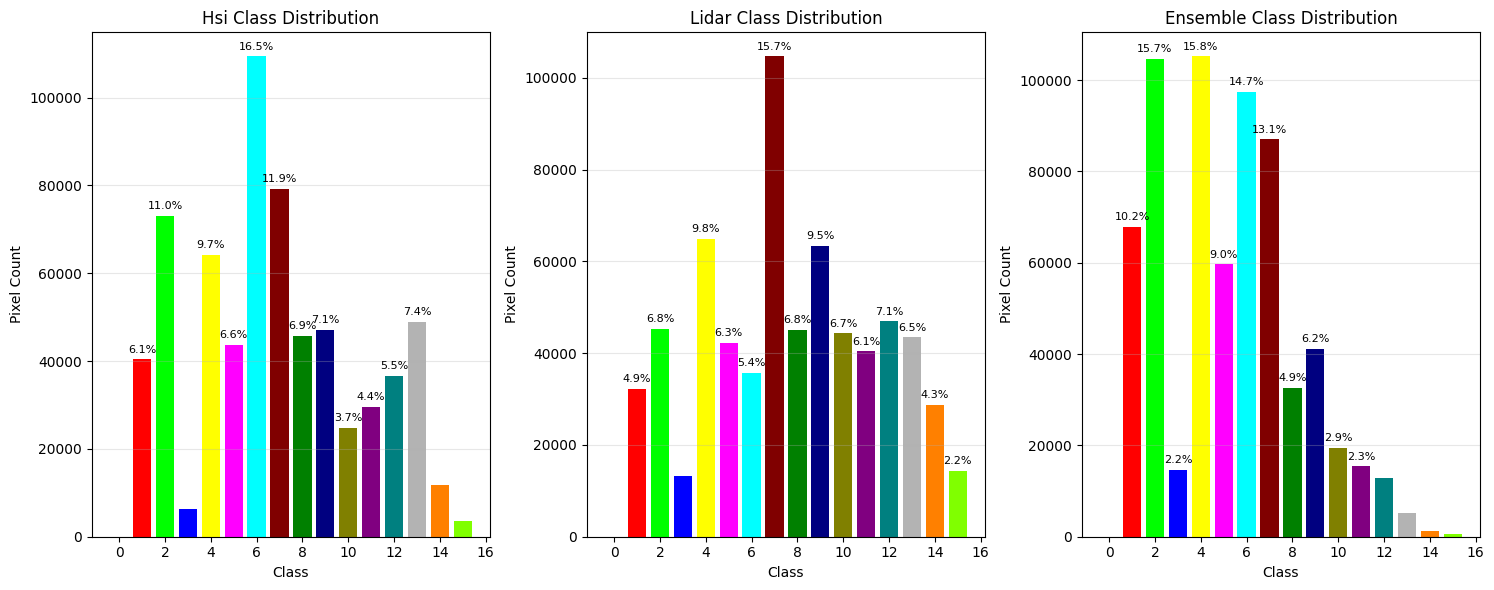

Comparing predictions...
Hsi model accuracy: 0.42%
Lidar model accuracy: 0.37%
Ensemble model accuracy: 0.39%

Detailed evaluation of combined model:
Mean accuracy (micro, no background): 0.98
Mean accuracy (macro, no background): 0.01


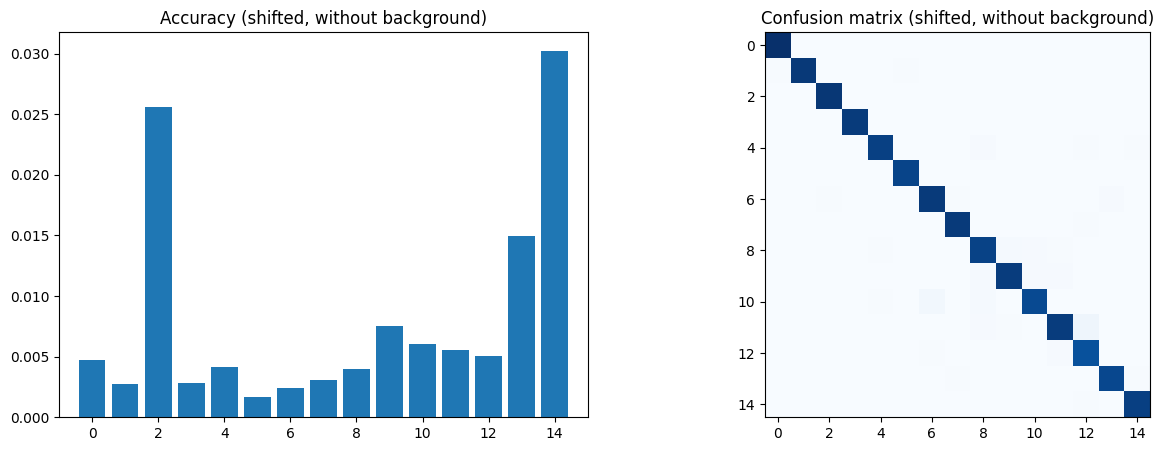

In [139]:
import warnings
warnings.filterwarnings("ignore")
pipeline_mergedata("random_forest_classifier_merge", custom_colors)